In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

###Architecture

In [2]:
class TinyMNIST(nn.Module):
    def __init__(self):
        super(TinyMNIST, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, bias=True)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(in_features=4 * 13 * 13, out_features=10, bias=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 676)
        x = self.fc(x)
        return x

###Train the model

In [3]:
print("Training model...")
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
model = TinyMNIST()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

model.train()
for epoch in range(5): # 3 Epochs is plenty for good results
    running_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/5 completed. Average Loss: {running_loss/len(train_loader):.4f}")

print("Training completed...")

Training model...


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


Epoch 1/5 completed. Average Loss: 0.2602
Epoch 2/5 completed. Average Loss: 0.1318
Epoch 3/5 completed. Average Loss: 0.0997
Epoch 4/5 completed. Average Loss: 0.0821
Epoch 5/5 completed. Average Loss: 0.0711
Training completed...


###Calibration to find activation scales

In [4]:
print("Calibrating for Integer Quantization...")
model.eval()
with torch.no_grad():
    # Pass one batch to get max activation value for Conv1
    calib_images = next(iter(train_loader))[0]
    conv1_out = model.relu(model.conv1(calib_images))
    max_a1 = torch.max(conv1_out).item()
print(f"Max activation value for Conv1: {max_a1}")

Calibrating for Integer Quantization...
Max activation value for Conv1: 2.471323013305664


###Calculate scales for quantization

In [5]:
# Calculate Scales for INT8 / INT32 Quantization
# Input image scale (Images are 0 to 1.0, map to 0 to 127)
S_in = 1.0 / 127.0

# Conv1 Scales
S_w1 = torch.max(torch.abs(model.conv1.weight)).item() / 127.0
S_b1 = S_in * S_w1  # Bias scale must match (input * weight) scale
S_a1 = max_a1 / 127.0 # Conv Output Scale

# Requantization multiplier for Conv1: M = (S_in * S_w1) / S_a1
M1 = (S_in * S_w1) / S_a1
# Convert float multiplier to fixed-point integer math (Multiplier + Bit Shift)
M1_SHIFT = 15
M1_NUM = int(round(M1 * (2 ** M1_SHIFT)))

# FC Scales
S_w2 = torch.max(torch.abs(model.fc.weight)).item() / 127.0
S_b2 = S_a1 * S_w2 # FC bias scale matches (conv_out * fc_weight)

### Quantize parameters

In [6]:
def quantize_int8(tensor, scale):
    return torch.clamp(torch.round(tensor / scale), -127, 127).to(torch.int8)

def quantize_int32(tensor, scale):
    # Biases can use full int32 range
    return torch.round(tensor / scale).to(torch.int32)

q_conv_w = quantize_int8(model.conv1.weight, S_w1)
q_conv_b = quantize_int32(model.conv1.bias, S_b1)
q_fc_w = quantize_int8(model.fc.weight, S_w2)
q_fc_b = quantize_int32(model.fc.bias, S_b2)

### Extract and quantize 10 sample images

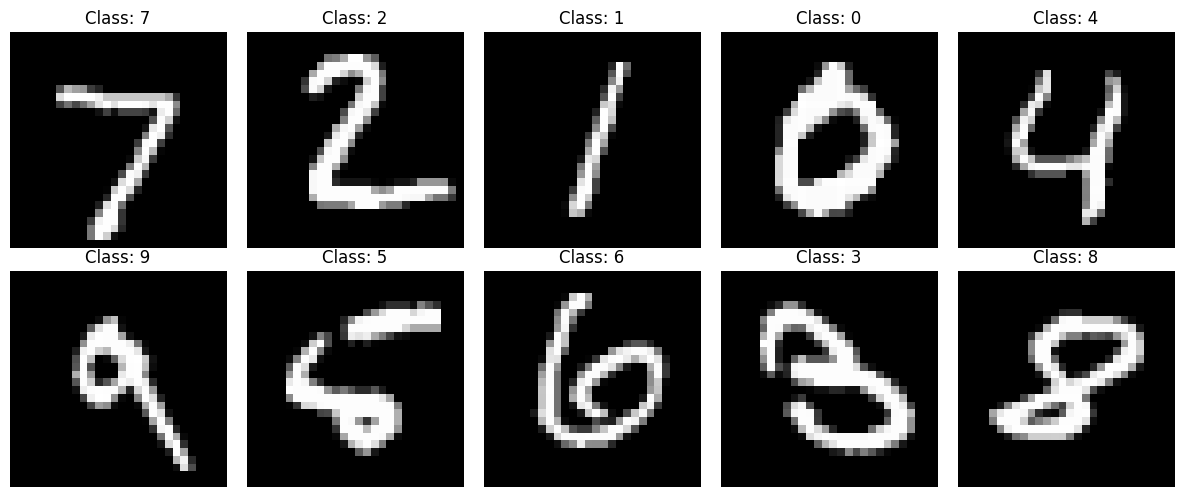

In [7]:
samples = {}
original_images = {} # Dictionary to store images before quantization

for img, label in test_dataset:
    lbl = label.item() if hasattr(label, 'item') else label

    if lbl not in samples:
        # Store the original, unquantized image
        # Using .clone() ensures we don't accidentally modify it later
        original_images[lbl] = img.clone() if isinstance(img, torch.Tensor) else img

        # Quantize the image to INT8 using S_in
        samples[lbl] = quantize_int8(img, S_in)

    if len(samples) == 10:
        break

# --- Visualization Code ---
# Create a 2x5 grid for the 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, (lbl, img_tensor) in enumerate(original_images.items()):
    ax = axes[i]

    # Format the image for matplotlib
    if isinstance(img_tensor, torch.Tensor):
        # Move to CPU and remove dummy dimensions
        img_disp = img_tensor.detach().cpu().squeeze()

        # PyTorch uses (C, H, W), but Matplotlib expects (H, W, C) for color images
        if img_disp.ndimension() == 3:
            img_disp = img_disp.permute(1, 2, 0)

        img_disp = img_disp.numpy()
    else:
        # Fallback if the dataset returns PIL images or raw numpy arrays
        img_disp = img_tensor

    # Display the image (use grayscale colormap if it's a 2D array)
    cmap = 'gray' if len(img_disp.shape) == 2 else None
    ax.imshow(img_disp, cmap=cmap)
    ax.set_title(f"Class: {lbl}")
    ax.axis('off')

plt.tight_layout()
plt.show()

###Export to C header

In [8]:
def c_array(tensor, name, c_type):
    flat = tensor.detach().cpu().numpy().flatten()
    arr_str = ", ".join([str(int(x)) for x in flat])
    return f"const {c_type} {name}[{len(flat)}] = {{{arr_str}}};\n"

with open("model_data.h", "w") as f:
    f.write("#ifndef MODEL_DATA_H\n#define MODEL_DATA_H\n#include <stdint.h>\n\n")

    # Export Requantization Fixed-Point Constants
    f.write(f"const int32_t M1_NUM = {M1_NUM};\n")
    f.write(f"const int32_t M1_SHIFT = {M1_SHIFT};\n\n")

    # Export Weights (int8) and Biases (int32)
    f.write(c_array(q_conv_w, "conv1_weights", "int8_t"))
    f.write(c_array(q_conv_b, "conv1_bias", "int32_t"))
    f.write(c_array(q_fc_w, "fc_weights", "int8_t"))
    f.write(c_array(q_fc_b, "fc_bias", "int32_t"))

    # Export INT8 Images
    for digit in range(10):
        f.write(c_array(samples[digit], f"sample_img_{digit}", "int8_t"))

    f.write("\n#endif\n")

print("Generated 'model_data.h' with pure integer quantization!")

Generated 'model_data.h' with pure integer quantization!
